In [1]:
import sys
sys.path.append("../..")
from src.sawmill.sawmill import Sawmill
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('expand_frame_repr', False)
pd.set_option('display.max_colwidth', None)

In [2]:
s = Sawmill("../../datasets_raw/tpc-ds/parameter_sweep_1.log", workdir="../../datasets/tpc-ds")
s.parse(regex_dict={"Date": r'\d{4}-\d{2}-\d{2}',
        "Time": r'\d{2}:\d{2}:\d{2}\.\d{3}(?= EST \[ )', 
        "sessionID" : r'(?<=EST \[ )\S+\.\S+',
        "tID": r'3/\d+(?= ] )'
        },message_prefix=r'\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}.\d{3}')

Initialized Sawmill with log file ../../datasets_raw/tpc-ds/parameter_sweep_1.log
Work directory set to ../../datasets/tpc-ds


Loading existing pkl file ../../datasets/tpc-ds/parameter_sweep_1.log_parsed_log_None_None.pkl...:   0%|      …

Loading existing pkl file ../../datasets/tpc-ds/parameter_sweep_1.log_parsed_templates_None_None.pkl...:   0%|…

Loading existing pkl file ../../datasets/tpc-ds/parameter_sweep_1.log_parsed_variables_None_None.pkl...:   0%|…

Parsing complete in 0.342651 seconds!


'0.342651'

In [3]:
s.parsed_variables.head(15)

,Name,Tag,Type,IsUninteresting,Occurrences,Preceding 3 tokens,Examples,From regex
0,Date,Date,num,False,78080,[],"[2023-11-06, 2023-11-07, 2023-11-08, 2023-11-09, 2023-11-10]",True
1,Time,Time,num,False,78080,[],"[16:34:40.799, 16:34:40.810, 16:34:40.811, 16:34:40.812, 16:34:40.813]",True
2,sessionID,sessionID,str,False,78080,[],"[65495bf0.179a, 65496dbc.231b, 65497f35.2c04, 6549a195.39d2, 6549c3f9.3d00]",True
3,tID,tID,str,True,78080,[],"[, 3/2461, 3/2462, 3/0, 3/2463]",True
4,aea309d3_23,port,num,False,128,"[127.0.0.1, port, =]","[52708, 39780, 50446, 45248, 56574]",False
5,5ebb5c01_12,statement,str,False,25856,"[:, statement, :]","[BEGIN, COMMIT]",False
6,9989ce8d_12,duration,num,False,38784,"[:, duration, :]","[0.084, 0.065, 0.031, 0.021, 0.032]",False
7,d2cdc31b_13,d2cdc31b_13,str,False,768,"[statement, :, SET]","[work_mem, max_parallel_workers, effective_cache_size, maintenance_work_mem, random_page_cost]",False
8,d2cdc31b_15,d2cdc31b_15,num,False,768,"[SET, <*>, =]","[128, 1, 262144, 32768, 4]",False
9,52e6a7ac_15,Filename,str,False,256,"[--, Filename, :]","[query012.sql, query020.sql]",False


In [4]:
s.parsed_templates.head(6)

,TemplateText,TemplateId,VariableIndices,RegexIndices,TemplateExample,Occurrences
0,<*0> <*1> EST [ <*2> ] [ unknown ] @ [ unknown ] LOG : connection received : host = 127.0.0.1 port = <*>,aea309d3,[23],"[0, 1, 4]",<*0> <*1> EST [ <*2> ] [ unknown ] @ [ unknown ] LOG : connection received : host = 127.0.0.1 port = 52708,128
1,"<*0> <*1> EST [ <*2> <*3> ] postgres@tpcds1 LOG : connection authenticated : identity = "" postgres "" method = scram-sha-256 ( /etc/postgresql/14/main/pg_hba.conf : 97 )",3de9afdd,[],"[0, 1, 4, 5]","<*0> <*1> EST [ <*2> <*3> ] postgres@tpcds1 LOG : connection authenticated : identity = "" postgres "" method = scram-sha-256 ( /etc/postgresql/14/main/pg_hba.conf : 97 )",128
2,"<*0> <*1> EST [ <*2> <*3> ] postgres@tpcds1 LOG : connection authorized : user = postgres database = tpcds1 SSL enabled ( protocol = TLSv1.3 , cipher = TLS_AES_256_GCM_SHA384 , bits = 256 )",101ebd1c,[],"[0, 1, 4, 5]","<*0> <*1> EST [ <*2> <*3> ] postgres@tpcds1 LOG : connection authorized : user = postgres database = tpcds1 SSL enabled ( protocol = TLSv1.3 , cipher = TLS_AES_256_GCM_SHA384 , bits = 256 )",128
3,<*0> <*1> EST [ <*2> <*3> ] postgres@tpcds1 LOG : statement : <*>,5ebb5c01,[12],"[0, 1, 4, 5]",<*0> <*1> EST [ <*2> <*3> ] postgres@tpcds1 LOG : statement : BEGIN,25856
4,<*0> <*1> EST [ <*2> <*3> ] postgres@tpcds1 LOG : duration : <*> ms,9989ce8d,[12],"[0, 1, 4, 5]",<*0> <*1> EST [ <*2> <*3> ] postgres@tpcds1 LOG : duration : 0.084 ms,38784
5,<*0> <*1> EST [ <*2> <*3> ] postgres@tpcds1 LOG : statement : SET <*> = <*> ;,d2cdc31b,"[13, 15]","[0, 1, 4, 5]",<*0> <*1> EST [ <*2> <*3> ] postgres@tpcds1 LOG : statement : SET work_mem = 128 ;,768


In [5]:
s.include_in_template('d2cdc31b_13')

In [6]:
s._parsed_variables.tail(6)

,Name,Tag,Type,IsUninteresting,Occurrences,Preceding 3 tokens,Examples,From regex
65,da4032f7_15,work_mem,num,False,128,"[SET, work_mem, =]","[128.0, 256.0]",False
66,9d2f8f03_15,max_parallel_workers,num,False,128,"[SET, max_parallel_workers, =]","[1.0, 2.0]",False
67,df623689_15,effective_cache_size,num,False,128,"[SET, effective_cache_size, =]","[262144.0, 524288.0]",False
68,97a1388a_15,maintenance_work_mem,num,False,128,"[SET, maintenance_work_mem, =]","[32768.0, 65536.0]",False
69,9eea70b1_15,random_page_cost,num,False,128,"[SET, random_page_cost, =]","[4.0, 1000.0]",False
70,8d5769b2_15,seq_page_cost,num,False,128,"[SET, seq_page_cost, =]","[1.0, 1000.0]",False


In [7]:
s.parsed_variables.shape

In [8]:
s.set_causal_unit("sessionID")
s.prepare(count_occurences=True, custom_agg={'sessionID': ['mode']}, reject_prunable_edges=False)

Causal unit set to sessionID (tag: sessionID) 


Loading existing pkl file ../../datasets/tpc-ds/parameter_sweep_1.log_prepared_log_sessionID_None.pkl...:   0%…

Loading existing pkl file ../../datasets/tpc-ds/parameter_sweep_1.log_prepared_variables_sessionID_None.pkl...…

Preparation complete in 0.075838 seconds! 172 of the 29584 possible edges were auto-rejected.


'0.075838'

In [9]:
s.explore_candidate_causes("duration max")


Candidate cause exploration complete in 0.975075 seconds!


(           Candidate              Candidate Tag           Target         Slope       P-value Candidate->Target Edge Status Target->Candidate Edge Status
 0   5da61167_14+mean                  time mean  9989ce8d_12+max    505.620725  2.448248e-42                     Undecided                     Undecided
 1   da4032f7_15+mean              work_mem mean  9989ce8d_12+max -20347.125686  1.533495e-23                     Undecided                     Undecided
 2           Date+min                   Date min  9989ce8d_12+max     -6.042776  1.833967e-15                     Undecided                     Undecided
 3   8d5769b2_15+mean         seq_page_cost mean  9989ce8d_12+max   1286.214372  2.201551e-05                     Undecided                     Undecided
 4           Time+max                   Time max  9989ce8d_12+max     17.799654  3.270357e-03                     Undecided                     Undecided
 5   9eea70b1_15+mean      random_page_cost mean  9989ce8d_12+max   -619.944

In [10]:
s.inspect('5da61167_26 mean')

Information about prepared variable 5da61167_26+mean:

--> Variable Information about 5da61167_26:


,Name,Tag,Type,IsUninteresting,Occurrences,Preceding 3 tokens,Examples,From regex
64,5da61167_26,5da61167_26,num,False,128,"[127.0.0.1, port, =]","[52708, 39780, 50446, 45248, 56574]",False


--> Template Information about 5da61167:


,TemplateText,TemplateId,VariableIndices,RegexIndices,TemplateExample,Occurrences
96,<*0> <*1> EST [ <*2> ] postgres@tpcds1 LOG : disconnection : session time : <*> user = postgres database = tpcds1 host = 127.0.0.1 port = <*>,5da61167,"[14, 26]","[0, 1, 4]",<*0> <*1> EST [ <*2> ] postgres@tpcds1 LOG : disconnection : session time : 1:15:55.940 user = postgres database = tpcds1 host = 127.0.0.1 port = 52708,128


--> Causal Unit Partial Information:


,5da61167_26+mean (candidate)
sessionID+mode,
65495bf0.179a,52708.0
65496dbc.231b,39780.0
65497f35.2c04,50446.0
6549a195.39d2,45248.0
6549c3f9.3d00,56574.0
6549d952.40db,58080.0
6549eeb8.4308,59468.0
654a1374.4649,47112.0
654a3884.49b7,59652.0



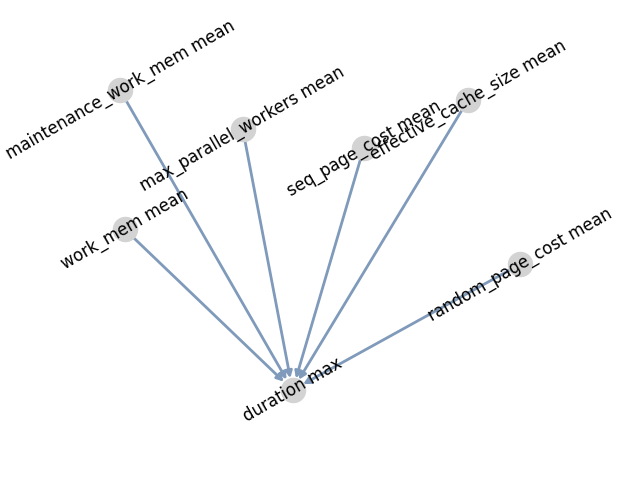

(0.07525510204081633, 'da4032f7_15+mean', '')

In [11]:
s.accept('work_mem mean', 'duration max', interactive=False)
s.accept('seq_page_cost mean', 'duration max', interactive=False)
s.accept('random_page_cost mean', 'duration max', interactive=False)
s.accept('max_parallel_workers mean','duration max', interactive=False)
s.accept('maintenance_work_mem mean', 'duration max', interactive=False)
s.accept('effective_cache_size mean', 'duration max', interactive=False)
s.reject_undecided_incoming('duration max')

In [12]:
from src.sawmill.tag_utils import TagUtils

effects_df = pd.DataFrame(
    columns=["scenario", "cause", "effect", "unadjusted_ate", "adjusted_ate"]
)
scenario = "base"
for node in s._graph.nodes:
    if node == "9989ce8d_12+max":
        continue
    cause = TagUtils.get_tag(s.prepared_variables, node)
    effects_df.loc[len(effects_df)] = {
        "scenario": scenario,
        "cause": cause,
        "effect": "duration max",
        "unadjusted_ate": s.get_unadjusted_ate(cause, "duration max"),
        "adjusted_ate": s.get_adjusted_ate(cause, "duration max"),
    }
effects_df

,scenario,cause,effect,unadjusted_ate,adjusted_ate
0,base,work_mem mean,duration max,-20347.125686,-20347.125685
1,base,seq_page_cost mean,duration max,1286.214372,1286.214371
2,base,random_page_cost mean,duration max,-619.944708,-619.944708
3,base,max_parallel_workers mean,duration max,-16828.958484,-16828.958431
4,base,maintenance_work_mem mean,duration max,0.282142,0.282142
5,base,effective_cache_size mean,duration max,-0.012924,-0.012924


---

## Scenario A

As we see, in the base case we have all the data available, so there is no confounding going on. Let's try to trade off the amount of working memory and the degree of parallelism in the data:

In [13]:
allowed_fully = s._prepared_log[((s._prepared_log['da4032f7_15+mean'] == 128) & (s._prepared_log['9d2f8f03_15+mean'] == 2)) | ((s._prepared_log['da4032f7_15+mean'] == 256) & (s.prepared_log['9d2f8f03_15+mean'] == 1))].copy()
allowed_half = s.prepared_log[((s.prepared_log['da4032f7_15+mean'] == 128) & (s.prepared_log['9d2f8f03_15+mean'] == 1)) | ((s.prepared_log['da4032f7_15+mean'] == 256) & (s.prepared_log['9d2f8f03_15+mean'] == 2))].copy()
allowed_half.drop_duplicates(inplace=True, subset=['da4032f7_15+mean', 'df623689_15+mean', '97a1388a_15+mean', '9d2f8f03_15+mean', '9eea70b1_15+mean', '8d5769b2_15+mean'])

In [14]:
filtered = pd.concat([allowed_fully, allowed_half])

In [19]:
l = s._prepared_log.index.difference(filtered.index)
len(l)

In [21]:
# Read the file  at ../../datasets_raw/tpc-ds/parameter_sweep_1.log line by line, 
# and write to a new file at ../../datasets_raw/tpc-ds/parameter_sweep_1_filtered.log.
# If a line includes the words "connection received" and any of the elements of l,
# do not write that line to the new file, and do not write any subsequent lines until
# the next line that includes the words "connection received". 

with open("../../datasets_raw/tpc-ds/parameter_sweep_1.log", "r") as f:
    with open("../../datasets_raw/tpc-ds/parameter_sweep_1_filtered.log", "w") as g:
        skip_mode = False
        for line in f:
            if "connection received" in line:
                if any([x in line for x in l]):
                    skip_mode = True
                else:
                    skip_mode = False
            if not skip_mode:
                g.write(line)

In [14]:
s_filtered = Sawmill("../../datasets_raw/tpc-ds/parameter_sweep_1_filtered.log", workdir="../../datasets/tpc-ds")
s_filtered.parse(regex_dict={"Date": r'\d{4}-\d{2}-\d{2}',
        "Time": r'\d{2}:\d{2}:\d{2}\.\d{3}(?= EST \[ )', 
        "sessionID" : r'(?<=EST \[ )\S+\.\S+',
        "tID": r'3/\d+(?= ] )'
        },message_prefix=r'\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}.\d{3}', force=True, enable_gpt_tagging=True)

Initialized Sawmill with log file ../../datasets_raw/tpc-ds/parameter_sweep_1_filtered.log
Work directory set to ../../datasets/tpc-ds
Parsing file: ../../datasets_raw/tpc-ds/parameter_sweep_1_filtered.log


Reading and tokenizing log lines...:   0%|          | 0/507648 [00:00<?, ?it/s]

Determining template for each line...:   0%|          | 0/58560 [00:00<?, ?it/s]

Extracting variables from each log message...:   0%|          | 0/98 [00:00<?, ?it/s]

Determining variable types...:   0%|          | 0/67 [00:00<?, ?it/s]

Casting date variables...:   0%|          | 0/1 [00:00<?, ?it/s]

Casting date variables round 2...:   0%|          | 0/58560 [00:00<?, ?it/s]

~/logs-venv/lib/python3.11/site-packages/tqdm/std.py:920: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return getattr(df, df_function)(wrapper, **kwargs)


Casting time variables...:   0%|          | 0/2 [00:00<?, ?it/s]

Casting time variables round 2...:   0%|          | 0/117120 [00:00<?, ?it/s]

~/logs-venv/lib/python3.11/site-packages/tqdm/std.py:920: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return getattr(df, df_function)(wrapper, **kwargs)


Casting numerical variables...:   0%|          | 0/7 [00:00<?, ?it/s]

Tagging variables...:   0%|          | 0/67 [00:00<?, ?it/s]

Detecting identifiers...:   0%|          | 0/67 [00:00<?, ?it/s]

Dumping pkl file to ../../datasets/tpc-ds/parameter_sweep_1_filtered.log_parsed_log_None_None.pkl...:   0%|   …

Dumping pkl file to ../../datasets/tpc-ds/parameter_sweep_1_filtered.log_parsed_templates_None_None.pkl...:   …

Dumping pkl file to ../../datasets/tpc-ds/parameter_sweep_1_filtered.log_parsed_variables_None_None.pkl...:   …

Parsing complete in 35.246736 seconds!


'35.246736'

In [26]:
run_durations = s_filtered.parsed_log['5da61167_14'].dropna()
# Sum them up
total_duration = run_durations.sum()
# Convert this seconds duration to days, hours, minutes, seconds
days = total_duration // 86400
hours = (total_duration - days * 86400) // 3600
minutes = (total_duration - days * 86400 - hours * 3600) // 60
seconds = total_duration - days* 86400 - hours * 3600 - minutes * 60
print(f"Total duration of runs: {days} days, {hours} hours, {minutes} minutes, {seconds} seconds")

Total duration of runs: 5.0 days, 2.0 hours, 45.0 minutes, 31.81000000005588 seconds


In [58]:
total_duration

In [16]:
s_filtered.include_in_template('d2cdc31b_13')

In [17]:
s_filtered.parsed_variables.shape

In [18]:
s_filtered.set_causal_unit("sessionID")
s_filtered.prepare(count_occurences=True, custom_agg={'sessionID': ['mode']}, reject_prunable_edges=False, force=True)

Causal unit set to sessionID (tag: sessionID) 
Determining the causal unit assignment...
Adding template occurrence count variables...
Dropped 1 uninteresting columns, out of an original total of 71.
Calculating aggregates for each causal unit...


Imputing missing values...:   0%|          | 0/310 [00:00<?, ?it/s]

Dropping aggregates that do not add information...


One-hot encoding categorical variables...:   0%|          | 0/57 [00:00<?, ?it/s]

Dumping pkl file to ../../datasets/tpc-ds/parameter_sweep_1_filtered.log_prepared_log_sessionID_None.pkl...:  …

Dumping pkl file to ../../datasets/tpc-ds/parameter_sweep_1_filtered.log_prepared_variables_sessionID_None.pkl…

Successfully prepared the log with causal unit sessionID (tag: sessionID)
Preparation complete in 4.406642 seconds! 172 of the 29584 possible edges were auto-rejected.


'4.406642'

In [19]:
s_filtered.explore_candidate_causes("duration mean", lasso_alpha=0.1)

Candidate cause exploration complete in 2.422277 seconds!


(           Candidate              Candidate Tag            Target        Slope       P-value Candidate->Target Edge Status Target->Candidate Edge Status
 0   5da61167_14+mean                  time mean  9989ce8d_12+mean     3.300329  0.000000e+00                     Undecided                     Undecided
 1   da4032f7_15+mean              work_mem mean  9989ce8d_12+mean  -123.438932  2.681628e-21                     Undecided                     Undecided
 2          Date+mean                  Date mean  9989ce8d_12+mean    -0.039341  1.377332e-11                     Undecided                     Undecided
 3   8d5769b2_15+mean         seq_page_cost mean  9989ce8d_12+mean    11.177583  4.372311e-09                     Undecided                     Undecided
 4   9d2f8f03_15+mean  max_parallel_workers mean  9989ce8d_12+mean  5127.647088  1.219556e-02                     Undecided                     Undecided
 5          Time+mean                  Time mean  9989ce8d_12+mean     0.070


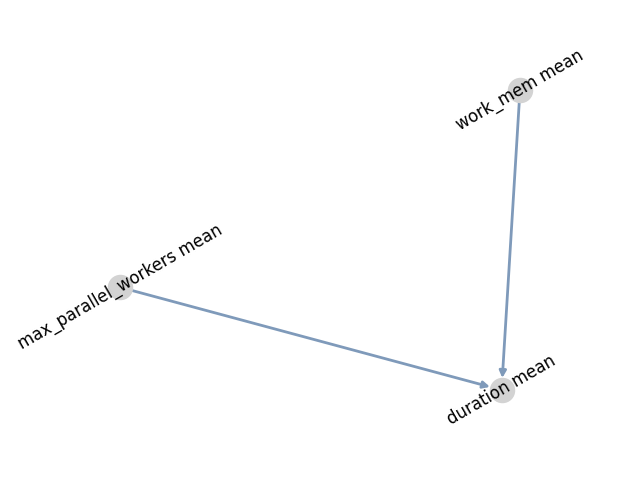

(0.1607843137254902, 'da4032f7_15+mean', '')

In [20]:
s_filtered.accept('work_mem mean', 'duration mean', interactive=False)
s_filtered.accept('max_parallel_workers mean','duration mean', interactive=True)

In [21]:
s_filtered.explore_candidate_causes('max_parallel_workers mean', lasso_alpha=0.1)

Candidate cause exploration complete in 2.425305 seconds!


(          Candidate  Candidate Tag            Target         Slope   P-value Candidate->Target Edge Status Target->Candidate Edge Status
 0  da4032f7_15+mean  work_mem mean  9d2f8f03_15+mean -2.604167e-03  0.000905                     Undecided                     Undecided
 1         Date+mean      Date mean  9d2f8f03_15+mean  4.105267e-07  0.205018                     Undecided                     Undecided,
 '2.425305')


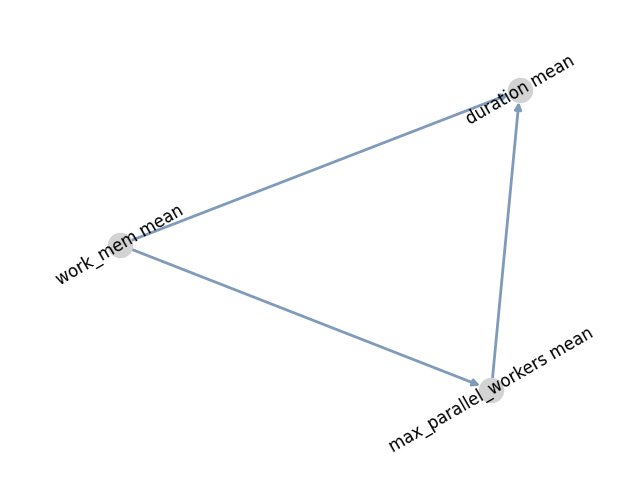

(0.32745098039215687, 'da4032f7_15+mean', '')

In [22]:
s_filtered.accept('work_mem mean', 'max_parallel_workers mean')

In [23]:
s_filtered.get_adjusted_ate('max_parallel_workers mean', 'duration mean')

In [43]:
s_filtered.get_unadjusted_ate('max_parallel_workers mean', 'duration mean')

In [39]:
# Color the edge from work_mem mean to max_parallel_workers mean red
s._graph.edges['da4032f7_15+mean', '9d2f8f03_15+mean']['color'] = '#ca3318'
s.save_graph('tpc-ds-graph.png')

In [56]:
print("ATE of max parallel workers on max latency:")
print(f"Unadjusted: {s.get_unadjusted_ate('max_parallel_workers mean', 'duration max')}\nAdjusted: {s.get_adjusted_ate('max_parallel_workers mean', 'duration max')}")

ATE of max parallel workers on max latency:
Unadjusted: 851349.4201041677
Adjusted: -16777.434452210553
